### This notebook compute "VCA12. Denisty Index of hydrometerological monitoring network stations in the basin" indicator for the 27 basins of IKI Project

Spanish: Índice de densidad de estaciones de la red de monitoreo hidrometeorológico en la cuenca

**Created:** 10/2025 by Serena Gilson (sgilson@rti.org)  

**Project #:** 0219481  

**Last modified:** 1/12/2026 by Sophia Bakar (sbakar@rti.org)

**Status:** Complete and loaded in SQLite for the baseline and first future scenario. 

**QA Status:** reviewed by  

**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad

**Packages:** pandas, numpy, geopandas, sqlite3, matplotlib  
 
**Inputs:**   Shapefile of COMIDs and districts, Hidrometricas_SENAMHI_ANA_1980_2020

**Process:**  
- Divide el área de la cuenca en km² entre la densidad mínima de estaciones en km² sugerida por la Organización Meteorológica Mundial (OMM), es decir, 250 km²34. De acuerdo a la OMM, se recomienda contar con 1 estación por cada 250 km².  
- Divide el número de estaciones que se encuentran funcionando en la cuenca entre el resultado obtenido en el cálculo anterior.  
- Asigna el índice obtenido por cuenca a todos sus distritos correspondientes  
 
**Assumptions:** In this we approach we calculate one value for the entire watershed and assigning the same value to all COMIDs within the watershed. Depending on the scale of analysis this might not be that telling of an indicator. 
 
**N/A Handling:** Cuencas with no stations as 

**Future work:**  Possibly modify to find the number of stations per area of drenaje (as calculated using the AHD, query the the base de datos to calculate the total area de drenaje). This would require querying the database and calculating the area each time.  
 
**Notes:** COMIDs with no density value were left as NaN.  

General Methodology:  
1. Spatially join stations with COMIDs. Count the number of stations per COMID.  
2. Spatially join the stations per subbasin with the larger basin areas. Count the number of stations per cuenca.   
3. Calculate the density of stations per basin by dividing the station count by COMID area and again by 250 (see *Assumptions* above).  
4. Assign cuenca-level densities to all COMIDs within the Cuenca.  
5. Round density values to 2 decimal places.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
# set up user and database path
#user = 'jmayo'
#user= 'cpickering'
#user = 'sgilson'
#user = 'nreynolds'
user = 'sbakar'
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"

In [3]:
# set up indicator ID and get scenarios from database
IndID= 512 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()

In [4]:
# define filepaths for input data
#subbasins_shapefile = fr"C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp"
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"

#stations_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/hidrometricas_ANA_SENAMHI_1981-2020.shp'
stations_shp = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\hidrometricas_ANA_SENAMHI_1981-2020.shp"

In [5]:
# read in input data
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
stations_gdf = gpd.read_file(stations_shp).to_crs('EPSG:32718')

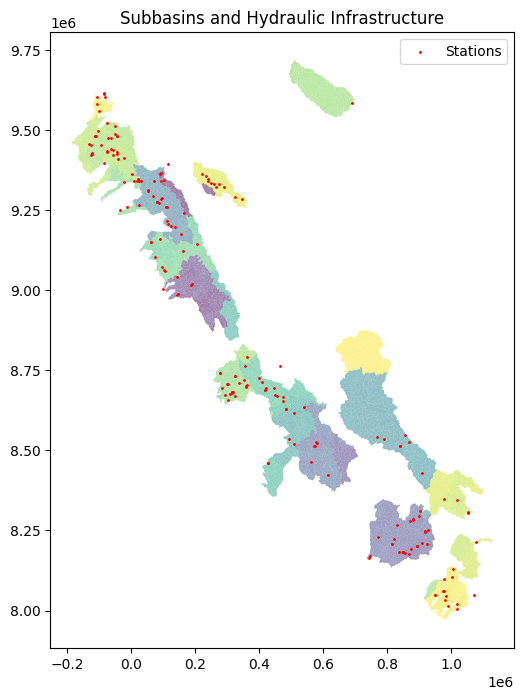

In [6]:
# Plot subbasins and bocatomas on the same plot for quick check on CRS alignment 
fig, ax = plt.subplots(figsize=(10, 8))

# Plot subbasins
subbasins_gdf.plot(ax=ax, column='IDDIST', legend=True, cmap='viridis', alpha=0.5)

# Plot stations
stations_gdf.plot(ax=ax, color='red', markersize=1, label='Stations')

# Add title and legend
plt.title('Subbasins and Hydraulic Infrastructure')
plt.legend()

# Show the plot
plt.show()

In [7]:
# count features per basin; group COMIDs by cuenca and calculate the total stations and area per cuenca

# Get cuenca areas
cuenca_areas = subbasins_gdf.groupby('Cuenca')['AREASQKM'].sum().reset_index()
cuenca_areas = cuenca_areas.rename(columns={'AREASQKM': 'Cuenca_Area_km2'})

# Spatial join to assign each station to a COMID
stations_with_comid = gpd.sjoin(stations_gdf, subbasins_gdf[['COMID', 'Cuenca', 'geometry']], 
                                  how='left', predicate='within')

# Count unique stations per Cuenca
cuenca_station_counts = stations_with_comid.groupby('Cuenca').size().reset_index(name='Station_Count')

# Merge area and station counts
cuenca_data = cuenca_areas.merge(cuenca_station_counts, on='Cuenca', how='left')
cuenca_data['Station_Count'] = cuenca_data['Station_Count']

# Calculate density per Cuenca (stations / (area / 250))
cuenca_data['Cuenca_Density'] = (cuenca_data['Station_Count'] / (cuenca_data['Cuenca_Area_km2'] / 250)).round(2)

# Assign Cuenca-level density to all COMIDs within that Cuenca
subbasins_gdf = subbasins_gdf.merge(cuenca_data[['Cuenca', 'Station_Count', 'Cuenca_Area_km2', 'Cuenca_Density']], 
                                      on='Cuenca', how='left')

print(f"Total COMIDs: {len(subbasins_gdf)}")
print(f"Unique Cuencas: {subbasins_gdf['Cuenca'].nunique()}")
print(f"\nSample of data:")
print(subbasins_gdf[['COMID', 'Cuenca', 'Station_Count', 'Cuenca_Area_km2', 'Cuenca_Density']].head(10))

Total COMIDs: 3655
Unique Cuencas: 33

Sample of data:
       COMID                     Cuenca  Station_Count  Cuenca_Area_km2  \
0  311153600               Cuenca Ilave            1.0         8188.237   
1  310832400               Cuenca Ramis            4.0        15730.639   
2  310825700               Cuenca Ramis            4.0        15730.639   
3  310282400                 Cuenca Ica            2.0         7380.419   
4  308754600             Cuenca Mantaro           20.0        34543.014   
5  307736500               Cuenca Santa            3.0        11636.269   
6  307078200             Cuenca Chicama            3.0         4624.731   
7  307183500               Cuenca Moche            1.0         2121.722   
8  306538400  Cuenca Chancay-Lambayeque            1.0         4143.413   
9  306599700  Cuenca Chancay-Lambayeque            1.0         4143.413   

   Cuenca_Density  
0            0.03  
1            0.06  
2            0.06  
3            0.07  
4            0.14  

In [8]:
#CALCULATION OF INDICATOR VALUE TO FIND DENSITY OF FEATURES PER 250 KM2

# Use Cuenca-level density (calculated in previous cell)
# Assign to 'value' column for database insert
subbasins_gdf['value'] = subbasins_gdf['Cuenca_Density'].round(2)

print(f"\nDensity Value Summary (by Cuenca):")
print(subbasins_gdf.groupby('Cuenca')[['value', 'Station_Count', 'Cuenca_Area_km2']].first())



Density Value Summary (by Cuenca):
                               value  Station_Count  Cuenca_Area_km2
Cuenca                                                              
Cuenca Alto Marañon             0.16           30.0        45776.233
Cuenca Camana                   0.15           10.0        17033.543
Cuenca Caplina                  0.20            1.0         1239.991
Cuenca Cascajal                  NaN            NaN         4140.581
Cuenca Chancay - Huaral         0.16            2.0         3084.537
Cuenca Chancay-Lambayeque       0.06            1.0         4143.413
Cuenca Chicama                  0.16            3.0         4624.731
Cuenca Chillon                  0.57            5.0         2188.402
Cuenca Chira                    0.18           13.0        17870.836
Cuenca Huamansaña               0.35            2.0         1440.941
Cuenca Ica                      0.07            2.0         7380.419
Cuenca Ilave                    0.03            1.0         8188.23

count    3608.000000
mean        0.132658
std         0.115086
min         0.020000
25%         0.040000
50%         0.140000
75%         0.160000
max         0.840000
Name: value, dtype: float64

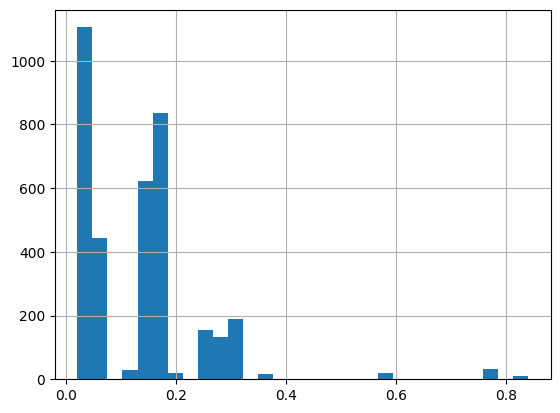

In [9]:
#QC HISTOGRAM AND SUMMARY STATS

#histogram of value above, excluding zeros
subbasins_gdf['value'][subbasins_gdf['value'] > 0].hist(bins=30)

#visual summary table, excluding zeros
subbasins_gdf['value'][subbasins_gdf['value'] > 0].describe()

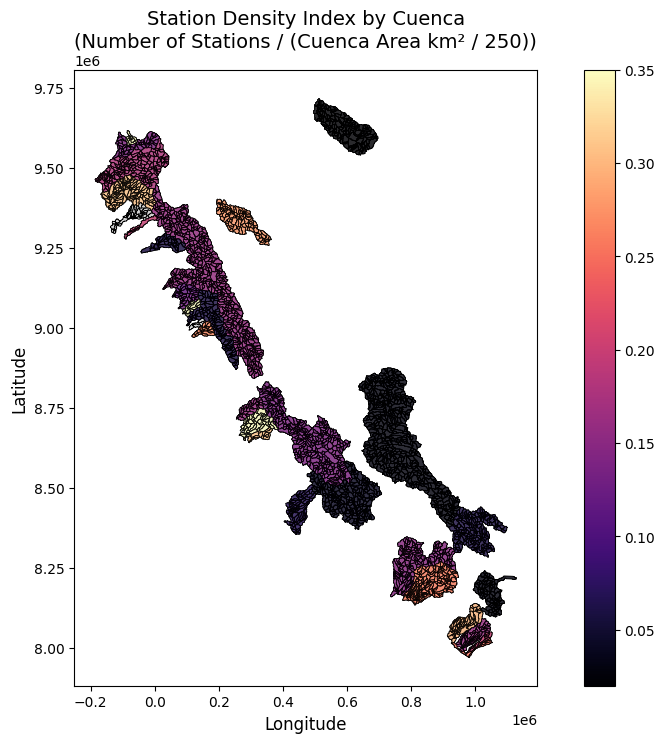

This reflects the WMO recommendation of 1 station per 250 km² at the basin (Cuenca) level

Note: All COMIDs within the same Cuenca have the same density value


In [11]:
# Plot the basins colored by station density (Cuenca-level)
fig, ax = plt.subplots(figsize=(12, 8))

# Plot all basins in grey first (this covers NaNs)
subbasins_gdf.plot(ax=ax,color='lightgrey',edgecolor='black',linewidth=0.5)

# Plot only valid values with scaled colorbar
data = subbasins_gdf[subbasins_gdf['value'].notna()]

if not data.empty:
    vmin = data['value'].quantile(0.02)
    vmax = data['value'].quantile(0.98)

    data.plot(
        ax=ax,
        column='value',
        legend=True,
        cmap='magma',
        alpha=0.8,
        edgecolor='black',
        linewidth=0.5,
        vmin=vmin,
        vmax=vmax
    )

# Titles and labels
ax.set_title('Station Density Index by Cuenca\n''(Number of Stations / (Cuenca Area km² / 250))',fontsize=14)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

plt.show()

print("This reflects the WMO recommendation of 1 station per 250 km² at the basin (Cuenca) level")
print("\nNote: All COMIDs within the same Cuenca have the same density value")


SQLITE INSERT 

In [12]:
# insert results into the database 
insert_data= subbasins_gdf 
value_column= 'value' #column with calculated values to be inserted into the database

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

for scn_id in scenario_ids:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""


In [13]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_gdf['value']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 512  Min: 0, Max: 1

=== Values to be inserted (by scenario) ===
   index    value
0    min     0.02
1    max     0.84
2  count  3608.00
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [14]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()